In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder


# Simple EDA

        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB
None
     

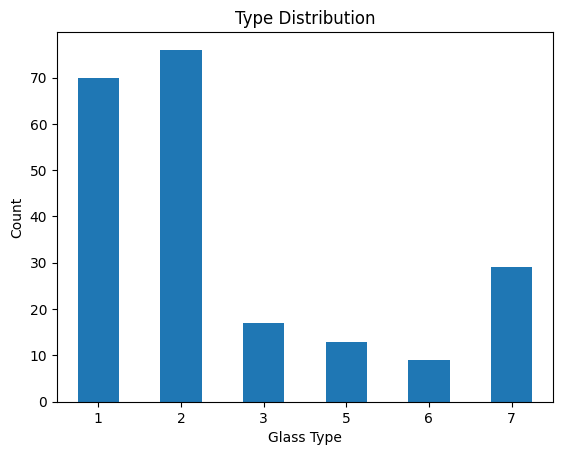

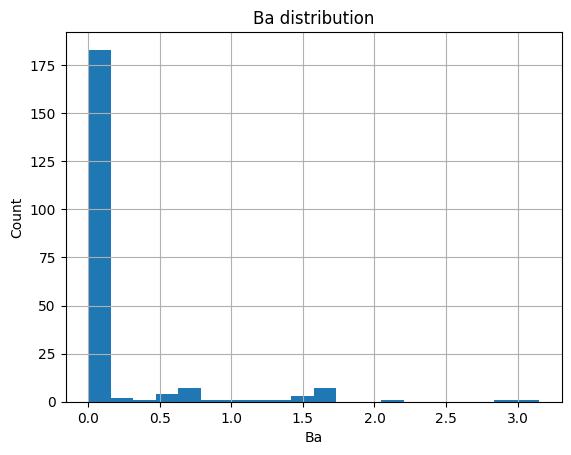

In [14]:
def load_data(path):
    df = pd.read_csv(path)
    return df

def inspect_df(df):
    print(df.head(5))
    print(df.info())
    print(df.describe())

def plot_type(df):
    df['Type'].value_counts().sort_index().plot(kind='bar')
    plt.xlabel('Glass Type')
    plt.ylabel('Count')
    plt.title('Type Distribution')
    plt.xticks(rotation=0)
    plt.show()

def plot_element(df, element):
    df[element].hist(bins=20)
    plt.xlabel(element)
    plt.ylabel('Count')
    plt.title(f'{element} distribution')
    plt.show()
    
df = load_data("../data/glass.csv")
inspect_df(df)
plot_type(df)
plot_element(df, 'Ba')

In [15]:
def split_data(df, test_size):
    y = df['Type']
    X = df.drop(columns=['Type'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, stratify=y)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(df, 0.2)
print(y_train.value_counts())

Type
2    61
1    56
7    23
3    14
5    10
6     7
Name: count, dtype: int64


# Logistic Regression Pipeline

In [16]:

def base_logi_model(X_train):
    """Build base model first no lda or smote"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        # multinomial LogisticRegression (sklearn's default for 3+ classes):
        # trains 6 separate scoring equations simultaneously (one per Type),
        # each with 5 coefficients + 1 intercept. NOT 6 separate boundaries
        # you could draw — softmax converts the 6 raw scores per point into
        # 6 competing probabilities that sum to 1, highest wins
        ('model', LogisticRegression())
    ])
    return pipeline

def logi_smote(X_train):
    """model with SMOTE"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = ImbPipeline(steps=[
        # ImbPipeline required here, NOT plain Pipeline — SMOTE changes row
        # count (synthesizes new minority-class rows)
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors =3)),
        ('model', LogisticRegression())
    ])
    return pipeline

def logi_lda(X_train):
    """model with lda"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', LogisticRegression())
    ])
    return pipeline

def logi_smote_lda(X_train):
    """model with SMOTE and lda"""
    column_names = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_names)
    ])
    pipeline = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        # SMOTE before LDA: LDA calculates each class's mean/spread to find
        # its separating axis — feeding it balanced data (post-SMOTE) gives
        # more stable class statistics than the raw, imbalanced version would
        ('lda', LinearDiscriminantAnalysis()),
        ('model', LogisticRegression())
    ])
    return pipeline

def hyperparameter_tunning_lda(pipeline, X_train, y_train):
    """tunnning for lda only"""
    params_grid = {
        'lda__n_components':[1, 2, 3, 4, 5],
    } 
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring = 'recall_macro') #optimze recall becuase not capturing the right type/class will be costly
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_


def matrix_calculation(y_test, pred):
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred, average='macro')
    recall = recall_score(y_test, pred, average='macro')
    f1 = f1_score(y_test, pred, average='macro')
    matrix = confusion_matrix(y_test, pred)
    return accuracy, precision, recall, f1, matrix


# Base model first
base_pipeline = base_logi_model(X_train)
base_pipeline = base_pipeline.fit(X_train, y_train)
pred_1 = base_pipeline.predict(X_test)
accuracy_1, precision_1, recall_1, f1_1, matrix_1 = matrix_calculation(y_test, pred_1)
print(f"Base model:\nAccuracy: {accuracy_1}\nPrecision: {precision_1}\nRecall: {recall_1}\nF1: {f1_1}")
print("=" * 50)

# Base model + SMOTE
smote_pipeline = logi_smote(X_train)
smote_pipeline = smote_pipeline.fit(X_train, y_train)
pred_2 = smote_pipeline.predict(X_test)
accuracy_2, precision_2, recall_2, f1_2, matrix_2 = matrix_calculation(y_test, pred_2)
print(f"Base + SMOTE:\nAccuracy: {accuracy_2}\nPrecision: {precision_2}\nRecall: {recall_2}\nF1: {f1_2}")
print("=" * 50)

# Base model + LDA
lda_pipeline = logi_lda(X_train)
best_lda_pipeline = hyperparameter_tunning_lda(lda_pipeline, X_train, y_train)
pred_3 = best_lda_pipeline.predict(X_test)
accuracy_3, precision_3, recall_3, f1_3, matrix_3 = matrix_calculation(y_test, pred_3)
print(f"Base + LDA (n_components={best_lda_pipeline.named_steps['lda'].n_components}):\nAccuracy: {accuracy_3}\nPrecision: {precision_3}\nRecall: {recall_3}\nF1: {f1_3}")
print("=" * 50)

# Base model + SMOTE + LDA
all_pipeline = logi_smote_lda(X_train)
best_all_pipeline = hyperparameter_tunning_lda(all_pipeline, X_train, y_train)
pred_4 = best_all_pipeline.predict(X_test)
accuracy_4, precision_4, recall_4, f1_4, matrix_4 = matrix_calculation(y_test, pred_4)
print(f"Base + SMOTE + LDA (n_components={best_all_pipeline.named_steps['lda'].n_components}):\nAccuracy: {accuracy_4}\nPrecision: {precision_4}\nRecall: {recall_4}\nF1: {f1_4}")
print("=" * 50)

recall_scores = {
    'base': recall_1,
    'smote': recall_2,
    'lda': recall_3,
    'smote_lda': recall_4
}

best_name = max(recall_scores, key=lambda name: recall_scores[name])
print(f"Best model: {best_name} (recall={recall_scores[best_name]})")

Base model:
Accuracy: 0.6046511627906976
Precision: 0.4703703703703704
Recall: 0.41984126984126985
F1: 0.4277146464646464
Base + SMOTE:
Accuracy: 0.627906976744186
Precision: 0.6138888888888888
Recall: 0.6793650793650793
F1: 0.6332462556600488


c:\Users\Edward\Desktop\python\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Base + LDA (n_components=5):
Accuracy: 0.5813953488372093
Precision: 0.5417892156862746
Recall: 0.5238095238095238
F1: 0.5284090909090909
Base + SMOTE + LDA (n_components=5):
Accuracy: 0.5813953488372093
Precision: 0.5662698412698413
Recall: 0.6119047619047618
F1: 0.5816589540727471
Best model: smote (recall=0.6793650793650793)


# Random Forest Pipeline

In [17]:
def base_rf_model():
    """Random Forest base model"""
    pipeline = Pipeline(steps=[
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def rf_smote():
    """base model + smote"""
    pipeline = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def rf_lda(X_train):
    """base model + lda"""
    column_name = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_name)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def rf_smote_lda(X_train):
    """base model + lda"""
    column_name = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_name)
    ])
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', RandomForestClassifier(random_state=42))
    ])
    return pipeline

def hyperparameter_tunning_tree(pipeline, X_train, y_train):
    """hyperparameter tunning for rf only"""
    params_grid = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth' : [5, 7, 9],
        'model__min_samples_split' : [2, 4, 6]
    }
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring='recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

def hyperparameter_tunning_tree_lda(pipeline, X_train, y_train):
    """hyperparameter tunning for rf with lda"""
    params_grid = {
        'lda__n_components' : [1, 2, 3, 4, 5],
        'model__n_estimators': [50, 100, 500],
        'model__max_depth' : [3, 5, 7],
        'model__min_samples_split' : [3, 6]
    }
    grid_search = GridSearchCV(pipeline, params_grid, cv = 5, scoring='recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

# Base rf model
base_rf = base_rf_model()
best_base_rf = hyperparameter_tunning_tree(base_rf, X_train, y_train)
pred_rf_1 = best_base_rf.predict(X_test)
accuracy_rf_1, precision_rf_1, recall_rf_1, f1_rf_1, matrix_rf_1 = matrix_calculation(y_test, pred_rf_1)

# Base rf + SMOTE 
smote_rf = rf_smote()
best_smote_rf = hyperparameter_tunning_tree(smote_rf, X_train, y_train)
pred_rf_2 = best_smote_rf.predict(X_test)
accuracy_rf_2, precision_rf_2, recall_rf_2, f1_rf_2, matrix_rf_2 = matrix_calculation(y_test, pred_rf_2)

# Base rf + lda
lda_rf = rf_lda(X_train)
best_lda_rf = hyperparameter_tunning_tree_lda(lda_rf, X_train, y_train)
pred_rf_3 = best_lda_rf.predict(X_test)
accuracy_rf_3, precision_rf_3, recall_rf_3, f1_rf_3, matrix_rf_3 = matrix_calculation(y_test, pred_rf_3)

# Base rf + SMOTE + lda
smote_lda_rf = rf_smote_lda(X_train)
best_smote_lda_rf = hyperparameter_tunning_tree_lda(smote_lda_rf, X_train, y_train)
pred_rf_4 = best_smote_lda_rf.predict(X_test)
accuracy_rf_4, precision_rf_4, recall_rf_4, f1_rf_4, matrix_rf_4, = matrix_calculation(y_test, pred_rf_4)

print(f"Base RF:\nAccuracy: {accuracy_rf_1}\nPrecision: {precision_rf_1}\nRecall: {recall_rf_1}\nF1: {f1_rf_1}")
print(f"Best params: {best_base_rf.named_steps['model'].get_params()}")
print("=" * 50)

print(f"RF + SMOTE:\nAccuracy: {accuracy_rf_2}\nPrecision: {precision_rf_2}\nRecall: {recall_rf_2}\nF1: {f1_rf_2}")
print(f"Best params: {best_smote_rf.named_steps['model'].get_params()}")
print("=" * 50)

print(f"RF + LDA:\nAccuracy: {accuracy_rf_3}\nPrecision: {precision_rf_3}\nRecall: {recall_rf_3}\nF1: {f1_rf_3}")
print(f"Best params: {best_lda_rf.named_steps['model'].get_params()}, n_components={best_lda_rf.named_steps['lda'].n_components}")
print("=" * 50)

print(f"RF + SMOTE + LDA:\nAccuracy: {accuracy_rf_4}\nPrecision: {precision_rf_4}\nRecall: {recall_rf_4}\nF1: {f1_rf_4}")
print(f"Best params: {best_smote_lda_rf.named_steps['model'].get_params()}, n_components={best_smote_lda_rf.named_steps['lda'].n_components}")
print("=" * 50)

recall_scores_rf = {
    'base': recall_rf_1,
    'smote': recall_rf_2,
    'lda': recall_rf_3,
    'smote_lda': recall_rf_4
}

best_name_rf = max(recall_scores_rf, key=lambda name: recall_scores_rf[name])
print(f"Best RF model: {best_name_rf} (recall={recall_scores_rf[best_name_rf]})")




Base RF:
Accuracy: 0.7209302325581395
Precision: 0.6759259259259259
Recall: 0.6365079365079365
F1: 0.6486590038314176
Best params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 6, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
RF + SMOTE:
Accuracy: 0.6511627906976745
Precision: 0.5724264705882353
Recall: 0.5587301587301586
F1: 0.5608015640273705
Best params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 9, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jo

## Feature importance

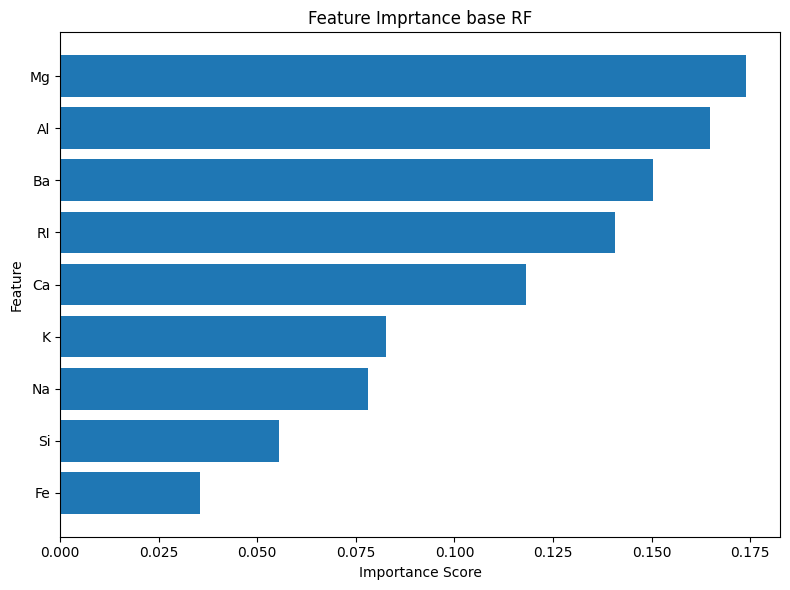

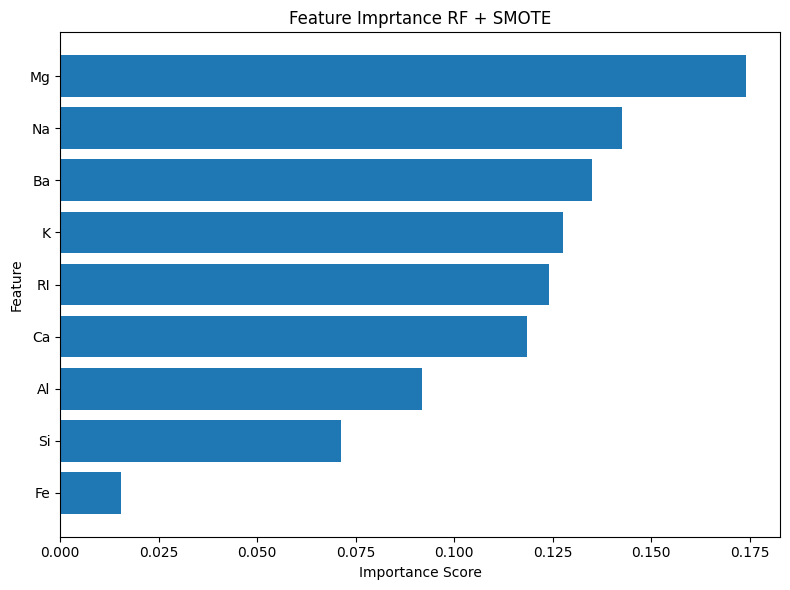

"\nWhen applied SMOTE, the model's most important feature shifted from Al to Mg\n — suggesting the original imbalanced training data caused the model to over-rely on whatever separated the majority classes best, \nwhile balancing let it discover Mg's value for distinguishing the rarer glass types, which lines up with the recall improvement measured.\n"

In [18]:
def feature_importance(tree_pipeline, X_train):
    """see the importance of each feature in the tree model"""
    feature_names = list(X_train.columns)
    scores = tree_pipeline.named_steps['model'].feature_importances_
    pairs = dict(zip(feature_names, scores))
    return pairs


def plot_feature_importance(pairs, title):
    """Horizontal bar chart: importance score (x) vs feature name (y)"""
    sorted_pairs = dict(sorted(pairs.items(), key=lambda item: item[1])) #sort by value
    plt.figure(figsize=(8, 6))
    plt.barh(list(sorted_pairs.keys()), list(sorted_pairs.values()))
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.title(title)
    plt.tight_layout()
    plt.show()


rf_base = feature_importance(best_base_rf, X_train)
plot_feature_importance(rf_base, "Feature Imprtance base RF")

rfsmote = feature_importance(best_smote_rf, X_train)
plot_feature_importance(rfsmote, "Feature Imprtance RF + SMOTE")
"""
When applied SMOTE, the model's most important feature shifted from Al to Mg
 — suggesting the original imbalanced training data caused the model to over-rely on whatever separated the majority classes best, 
while balancing let it discover Mg's value for distinguishing the rarer glass types, which lines up with the recall improvement measured.
"""

# XGBoost Pipeline

In [ ]:
def base_xgboost():
    """base xgboost model"""
    pipeline = Pipeline(steps=[
        ('model', XGBClassifier(random_state = 42))     
    ])
    return pipeline

def smote_xgboost():
    """SMOTE + xgboost mode"""
    pipeline = ImbPipeline(steps=[
        ('smote', SMOTE(random_state=42 , k_neighbors=3)),
        ('model', XGBClassifier(random_state = 42))
    ])
    return pipeline

def lda_xgboost(X_train):
    """LDA + xgboost model"""
    column_name = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_name)
    ])
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', XGBClassifier(random_state=42))
    ])
    return pipeline

def smote_lda_xgboost(X_train):
    """SMOTE + LDA +xgboost model"""
    column_name = list(X_train.columns)
    preprocessor = ColumnTransformer(transformers=[
        ('nums', StandardScaler(), column_name)
    ])
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('lda', LinearDiscriminantAnalysis()),
        ('model', XGBClassifier(random_state=42))
    ])
    return pipeline

def hyperparameter_tunning_xgboost(pipeline, X_train, y_train):
    param_grid = {
        'model__n_estimators':[50, 100, 200],
        'model__max_depth':[4, 6],
        'model__min_child_weight': [1, 3],
        'model__learning_rate':[ 0.05, 0.1]
    }
    grid_search = GridSearchCV(pipeline, param_grid, cv = 5, scoring = 'recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

def hyperparameter_tunning_xgboost_lda(pipeline, X_train, y_train):
    param_grid = {
        'lda__n_components' : [1, 2, 3, 4, 5],
        'model__n_estimators':[50, 100, 200],
        'model__max_depth':[4, 6],
        'model__min_child_weight': [1, 3],
        'model__learning_rate':[ 0.05, 0.1]
    }
    grid_search = GridSearchCV(pipeline, param_grid, cv = 5, scoring = 'recall_macro')
    grid_search.fit(X_train, y_train)
    return grid_search.best_estimator_

from sklearn.preprocessing import LabelEncoder

# XGBoost requires labels as consecutive integers starting at 0.
# Glass's real Type values are [1,2,3,5,6,7] — not consecutive, not
# 0-indexed (Type 4 doesn't exist in this dataset at all) — sklearn
# models (LogReg, RF) tolerate this fine, XGBoost's implementation does not
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  # fit on train only
y_test_encoded = label_encoder.transform(y_test)        # reuse train's mapping, no re-fit

# Base xgboost
base_xgb = base_xgboost()
best_base_xgb = hyperparameter_tunning_xgboost(base_xgb, X_train, y_train_encoded)
pred_xgb_1 = best_base_xgb.predict(X_test)
accuracy_xgb_1, precision_xgb_1, recall_xgb_1, f1_xgb_1, matrix_xgb_1 = matrix_calculation(y_test_encoded, pred_xgb_1)

# Base xgboost + SMOTE
smote_xgb = smote_xgboost()
best_smote_xgb = hyperparameter_tunning_xgboost(smote_xgb, X_train, y_train_encoded)
pred_xgb_2 = best_smote_xgb.predict(X_test)
accuracy_xgb_2, precision_xgb_2, recall_xgb_2, f1_xgb_2, matrix_xgb_2 = matrix_calculation(y_test_encoded, pred_xgb_2)

# Base xgboost + LDA
lda_xgb = lda_xgboost(X_train)
best_lda_xgb = hyperparameter_tunning_xgboost_lda(lda_xgb, X_train, y_train_encoded)
pred_xgb_3 = best_lda_xgb.predict(X_test)
accuracy_xgb_3, precision_xgb_3, recall_xgb_3, f1_xgb_3, matrix_xgb_3 = matrix_calculation(y_test_encoded, pred_xgb_3)

# Base xgboost + SMOTE + LDA
smote_lda_xgb = smote_lda_xgboost(X_train)
best_smote_lda_xgb = hyperparameter_tunning_xgboost_lda(smote_lda_xgb, X_train, y_train_encoded)
pred_xgb_4 = best_smote_lda_xgb.predict(X_test)
accuracy_xgb_4, precision_xgb_4, recall_xgb_4, f1_xgb_4, matrix_xgb_4 = matrix_calculation(y_test_encoded, pred_xgb_4)

print(f"Base XGBoost:\nAccuracy: {accuracy_xgb_1}\nPrecision: {precision_xgb_1}\nRecall: {recall_xgb_1}\nF1: {f1_xgb_1}")
print(f"Best params: {best_base_xgb.named_steps['model'].get_params()}")
print("=" * 50)

print(f"XGBoost + SMOTE:\nAccuracy: {accuracy_xgb_2}\nPrecision: {precision_xgb_2}\nRecall: {recall_xgb_2}\nF1: {f1_xgb_2}")
print(f"Best params: {best_smote_xgb.named_steps['model'].get_params()}")
print("=" * 50)

print(f"XGBoost + LDA:\nAccuracy: {accuracy_xgb_3}\nPrecision: {precision_xgb_3}\nRecall: {recall_xgb_3}\nF1: {f1_xgb_3}")
print(f"Best params: {best_lda_xgb.named_steps['model'].get_params()}, n_components={best_lda_xgb.named_steps['lda'].n_components}")
print("=" * 50)

print(f"XGBoost + SMOTE + LDA:\nAccuracy: {accuracy_xgb_4}\nPrecision: {precision_xgb_4}\nRecall: {recall_xgb_4}\nF1: {f1_xgb_4}")
print(f"Best params: {best_smote_lda_xgb.named_steps['model'].get_params()}, n_components={best_smote_lda_xgb.named_steps['lda'].n_components}")
print("=" * 50)

"""
If SMOTE introduces synthetic samples that don't perfectly represent the true minority-class distribution
(interpolated points between real ones, not real observations), XGBoost's sequential error-correction can end up overfitting to the synthetic patterns
 — chasing "errors" on fake data that don't reflect genuine glass chemistry as precisely as real samples would
"""
recall_scores_xgb = {
    'base': recall_xgb_1,
    'smote': recall_xgb_2,
    'lda': recall_xgb_3,
    'smote_lda': recall_xgb_4
}

best_name_xgb = max(recall_scores_xgb, key=lambda name: recall_scores_xgb[name])
print(f"Best XGBoost model: {best_name_xgb} (recall={recall_scores_xgb[best_name_xgb]})")

Base XGBoost:
Accuracy: 0.7674418604651163
Precision: 0.6399122807017544
Recall: 0.6150793650793651
F1: 0.6183231913455037
Best params: {'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': 3, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': Non